# Clustering : Customer Segmentation

**Goal:** Forming customer segmentation using unsupervised learning on a grocery firm's customer database.

---

## 📋 Table of Contents
1. [Setup and Data Loading](#setup-and-data-loading)
2. [Data Cleaning and Basic Sanity](#data-cleaning)
3. [Exploratory Data Analysis (EDA)](#eda)
4. [Feature Engineering](#feature-engineering)
5. [Outlier Treatment (Force-fitting)](#outlier-treatment)
6. [Feature Selection for Clustering](#feature-selection)
7. [Feature Scaling](#feature-scaling)
8. [PCA for Clustering Model](#pca-for-clustering)
9. [KMeans (Elbow + Silhouette)](#kmeans)
10. [Final Model (KMeans)](#final-model)
11. [PCA Visualization and Plots](#pca-visualization-and-plots)
12. [Cluster Profiling and Business Interpretation](#cluster-profiling)
13. [Final Customer Segmentation and Profiling](#final-customer-segmentation)

## 1. Setup and Data Loading <a id='setup-and-data-loading'></a>

In [1]:
import pandas as pd
import numpy as np
import statsmodels
import pandas_datareader
import matplotlib.pyplot as plt
import seaborn as sns
color = sns.color_palette()

import plotly.offline as py
from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)
import plotly.graph_objs as go

# Set to display all rows
pd.set_option('display.max_rows', None)

# Set to display all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# import cufflinks and offline mode
import cufflinks as cf
cf.go_offline()

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

import os

In [2]:
!pip install --upgrade pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 78.3 MB/s eta 0:00:00:00:01:01
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.26.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
ydata-profiling 4.18.1 requires pandas!=1.4.0,<3.0,>1.5, but you have pandas 3.0.1 which is incompatible.
google-colab 1.0.0 requires google-auth==2.38.0, but you have google-auth 2.47.0 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatibl

In [3]:
print("pandas:", pd.__version__)
print("statsmodels:", statsmodels.__version__)
print(os.listdir("../input"))

pandas: 2.2.2
statsmodels: 0.14.5
['datasets']


#### Folder Structure

In [4]:
os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

#### Load Data

In [5]:
df_raw = pd.read_csv("../input/datasets/imakash3011/customer-personality-analysis/marketing_campaign.csv", sep="\t")
df_raw.to_csv("data/raw/marketing_campaign_raw.csv", index=False)

df = df_raw.copy()

## 2. Data Cleaning and Basic Sanity <a id='data-cleaning'></a>

In [6]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.000,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.000,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.000,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.000,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.000,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [8]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

We can see that 24 records have null values in the income column.

In [9]:
df.duplicated().sum()

np.int64(0)

#### Handle Missing Values

In [10]:
df['Income'] = df['Income'].fillna(df['Income'].median())

#### Creating Age column

In [11]:
df['Age'] = 2026 - df['Year_Birth']

#### Creating Customer_For column

In [12]:
# Ensure datetime
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst=True)

# Snapshot date = newest customer
snapshot_date = df["Dt_Customer"].max()

# Customer tenure in days
df["Customer_For"] = (snapshot_date - df["Dt_Customer"]).dt.days

In [13]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Customer_For
0,5524,1957,Graduation,Single,58138.000,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,69,663
1,2174,1954,Graduation,Single,46344.000,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,72,113
2,4141,1965,Graduation,Together,71613.000,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,61,312
3,6182,1984,Graduation,Together,26646.000,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,42,139
4,5324,1981,PhD,Married,58293.000,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,45,161


#### Save cleaned dataset

In [14]:
df.to_csv("data/processed/eda_cleaned_data.csv", index=False)

## 3. Exploratory Data Analysis (EDA) <a id='eda'></a>

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


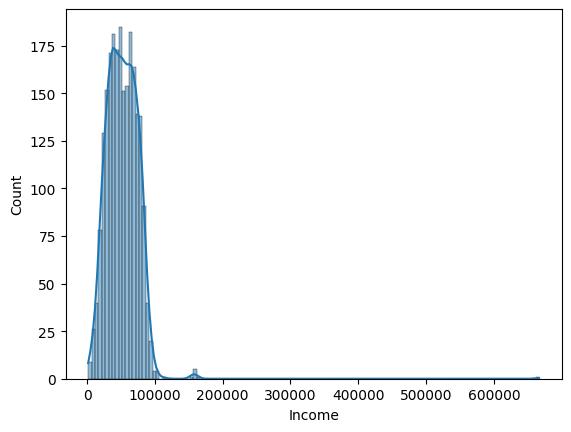

In [15]:
sns.histplot(df['Income'], kde=True)
plt.show()

#### Correlation

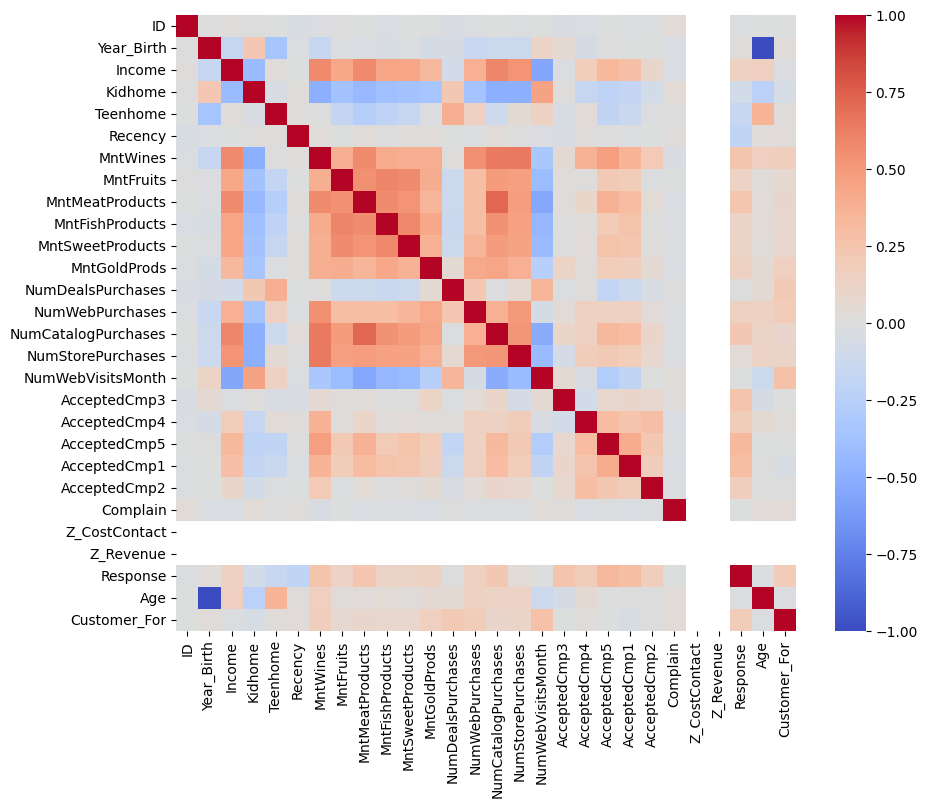

In [16]:
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(np.number).corr(), cmap="coolwarm")
plt.show()

In [17]:
df.describe(include='all')

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Customer_For
count,2240.000,2240.000,2240,2240,2240.000,2240.000,2240.000,2240,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000
unique,NaN,NaN,5,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Graduation,Married,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,1127,864,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,5592.160,1968.806,NaN,NaN,52237.975,0.444,0.506,2013-07-10 10:01:42.857142784,49.109,303.936,26.302,166.950,37.525,27.063,44.022,2.325,4.085,2.662,5.790,5.317,0.073,0.075,0.073,0.064,0.013,0.009,3.000,11.000,0.149,57.194,353.582
min,0.000,1893.000,NaN,NaN,1730.000,0.000,0.000,2012-07-30 00:00:00,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,3.000,11.000,0.000,30.000,0.000
25%,2828.250,1959.000,NaN,NaN,35538.750,0.000,0.000,2013-01-16 00:00:00,24.000,23.750,1.000,16.000,3.000,1.000,9.000,1.000,2.000,0.000,3.000,3.000,0.000,0.000,0.000,0.000,0.000,0.000,3.000,11.000,0.000,49.000,180.750
50%,5458.500,1970.000,NaN,NaN,51381.500,0.000,0.000,2013-07-08 12:00:00,49.000,173.500,8.000,67.000,12.000,8.000,24.000,2.000,4.000,2.000,5.000,6.000,0.000,0.000,0.000,0.000,0.000,0.000,3.000,11.000,0.000,56.000,355.500
75%,8427.750,1977.000,NaN,NaN,68289.750,1.000,1.000,2013-12-30 06:00:00,74.000,504.250,33.000,232.000,50.000,33.000,56.000,3.000,6.000,4.000,8.000,7.000,0.000,0.000,0.000,0.000,0.000,0.000,3.000,11.000,0.000,67.000,529.000
max,11191.000,1996.000,NaN,NaN,666666.000,2.000,2.000,2014-06-29 00:00:00,99.000,1493.000,199.000,1725.000,259.000,263.000,362.000,15.000,27.000,28.000,13.000,20.000,1.000,1.000,1.000,1.000,1.000,1.000,3.000,11.000,1.000,133.000,699.000


## 4. Feature Engineering <a id='feature-engineering'></a>

In [18]:
df = df.copy()

In [19]:
# Household structure
df['num_children'] = df['Kidhome'] + df['Teenhome']
df['has_kids'] = (df['num_children'] > 0).astype(int)

# Education indicators
df['is_grad'] = df['Education'].isin(['Graduation','Master','PhD']).astype(int)
df['is_undergrad'] = df['Education'].isin(['Basic','2n Cycle']).astype(int)

# Marital structure
df['is_single'] = df['Marital_Status'].isin(['Single','Divorced','Widow']).astype(int)
df['is_partnered'] = df['Marital_Status'].isin(['Married','Together']).astype(int)

# Spending features
spend_cols = [
    'MntWines','MntFruits','MntMeatProducts',
    'MntFishProducts','MntSweetProducts','MntGoldProds'
]
df['total_spend'] = df[spend_cols].sum(axis=1)
for col in spend_cols:
    df[f'{col}_ratio'] = np.where(df['total_spend'] > 0,df[col] / df['total_spend'],0)

# Purchase channel behavior
df['total_purchases'] = (
    df['NumWebPurchases'] +
    df['NumCatalogPurchases'] +
    df['NumStorePurchases']
)
df['web_purchase_ratio'] = np.where(
    df['total_purchases'] > 0, df['NumWebPurchases'] / df['total_purchases'],0)
df['store_purchase_ratio'] = np.where(
    df['total_purchases'] > 0,df['NumStorePurchases'] / df['total_purchases'],0)
df['catalog_purchase_ratio'] = np.where(
    df['total_purchases'] > 0,df['NumCatalogPurchases'] / df['total_purchases'],0)

# Discount sensitivity
df['deal_purchase_ratio'] = np.where(
    df['total_purchases'] > 0,df['NumDealsPurchases'] / df['total_purchases'],0)
df['is_discount_heavy'] = (df['deal_purchase_ratio'] > 0.5).astype(int)

# Campaign responsiveness
cmp_cols = ['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5']
df['campaign_accept_count'] = df[cmp_cols].sum(axis=1)
df['responded_any_campaign'] = (df['campaign_accept_count'] > 0).astype(int)

# Recency & engagement
df['is_recent_customer'] = (df['Recency'] <= 30).astype(int)
df['is_dormant_customer'] = (df['Recency'] >= 90).astype(int)

# Value indicators
df['is_high_spender'] = (df['total_spend'] > df['total_spend'].quantile(0.75)).astype(int)
df['is_low_spender'] = (df['total_spend'] < df['total_spend'].quantile(0.25)).astype(int)

#### Save engineered dataset

In [20]:
df.to_csv("data/processed/row_level_engineered_features.csv", index=False)

In [21]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Customer_For,num_children,has_kids,is_grad,is_undergrad,is_single,is_partnered,total_spend,MntWines_ratio,MntFruits_ratio,MntMeatProducts_ratio,MntFishProducts_ratio,MntSweetProducts_ratio,MntGoldProds_ratio,total_purchases,web_purchase_ratio,store_purchase_ratio,catalog_purchase_ratio,deal_purchase_ratio,is_discount_heavy,campaign_accept_count,responded_any_campaign,is_recent_customer,is_dormant_customer,is_high_spender,is_low_spender
count,2240.000,2240.000,2240.000,2240.000,2240.000,2240,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000
mean,5592.160,1968.806,52237.975,0.444,0.506,2013-07-10 10:01:42.857142784,49.109,303.936,26.302,166.950,37.525,27.063,44.022,2.325,4.085,2.662,5.790,5.317,0.073,0.075,0.073,0.064,0.013,0.009,3.000,11.000,0.149,57.194,353.582,0.950,0.715,0.885,0.115,0.352,0.645,605.798,0.458,0.050,0.250,0.072,0.051,0.120,12.537,0.329,0.504,0.164,0.247,0.064,0.298,0.207,0.323,0.097,0.250,0.250
min,0.000,1893.000,1730.000,0.000,0.000,2012-07-30 00:00:00,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,3.000,11.000,0.000,30.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,5.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,2828.250,1959.000,35538.750,0.000,0.000,2013-01-16 00:00:00,24.000,23.750,1.000,16.000,3.000,1.000,9.000,1.000,2.000,0.000,3.000,3.000,0.000,0.000,0.000,0.000,0.000,0.000,3.000,11.000,0.000,49.000,180.750,0.000,0.000,1.000,0.000,0.000,0.000,68.750,0.290,0.009,0.156,0.013,0.009,0.038,6.000,0.250,0.400,0.000,0.083,0.000,0.000,0.000,0.000,0.000,0.000,0.000
50%,5458.500,1970.000,51381.500,0.000,0.000,2013-07-08 12:00:00,49.000,173.500,8.000,67.000,12.000,8.000,24.000,2.000,4.000,2.000,5.000,6.000,0.000,0.000,0.000,0.000,0.000,0.000,3.000,11.000,0.000,56.000,355.500,1.000,1.000,1.000,0.000,0.000,1.000,396.000,0.457,0.030,0.233,0.048,0.033,0.086,12.000,0.333,0.500,0.150,0.200,0.000,0.000,0.000,0.000,0.000,0.000,0.000
75%,8427.750,1977.000,68289.750,1.000,1.000,2013-12-30 06:00:00,74.000,504.250,33.000,232.000,50.000,33.000,56.000,3.000,6.000,4.000,8.000,7.000,0.000,0.000,0.000,0.000,0.000,0.000,3.000,11.000,0.000,67.000,529.000,1.000,1.000,1.000,0.000,1.000,1.000,1045.500,0.639,0.070,0.328,0.105,0.070,0.170,18.000,0.400,0.600,0.250,0.333,0.000,0.000,0.000,1.000,0.000,0.250,0.250
max,11191.000,1996.000,666666.000,2.000,2.000,2014-06-29 00:00:00,99.000,1493.000,199.000,1725.000,259.000,263.000,362.000,15.000,27.000,28.000,13.000,20.000,1.000,1.000,1.000,1.000,1.000,1.000,3.000,11.000,1.000,133.000,699.000,3.000,1.000,1.000,1.000,1.000,1.000,2525.000,0.963,0.446,0.997,0.591,0.946,0.894,32.000,1.000,1.000,1.000,15.000,1.000,4.000,1.000,1.000,1.000,1.000,1.000
std,3246.662,11.984,25037.956,0.538,0.545,NaN,28.962,336.597,39.773,225.715,54.629,41.280,52.167,1.932,2.779,2.923,3.251,2.427,0.260,0.263,0.260,0.245,0.115,0.096,0.000,0.000,0.356,11.984,202.123,0.752,0.451,0.319,0.319,0.478,0.479,602.249,0.228,0.056,0.127,0.078,0.061,0.109,7.206,0.123,0.152,0.141,0.356,0.245,0.678,0.405,0.468,0.296,0.433,0.433


We see that max age is 133. Also, the mean value and max value differ quite a lot in income as well. So let's see if we have any outliers in the data.

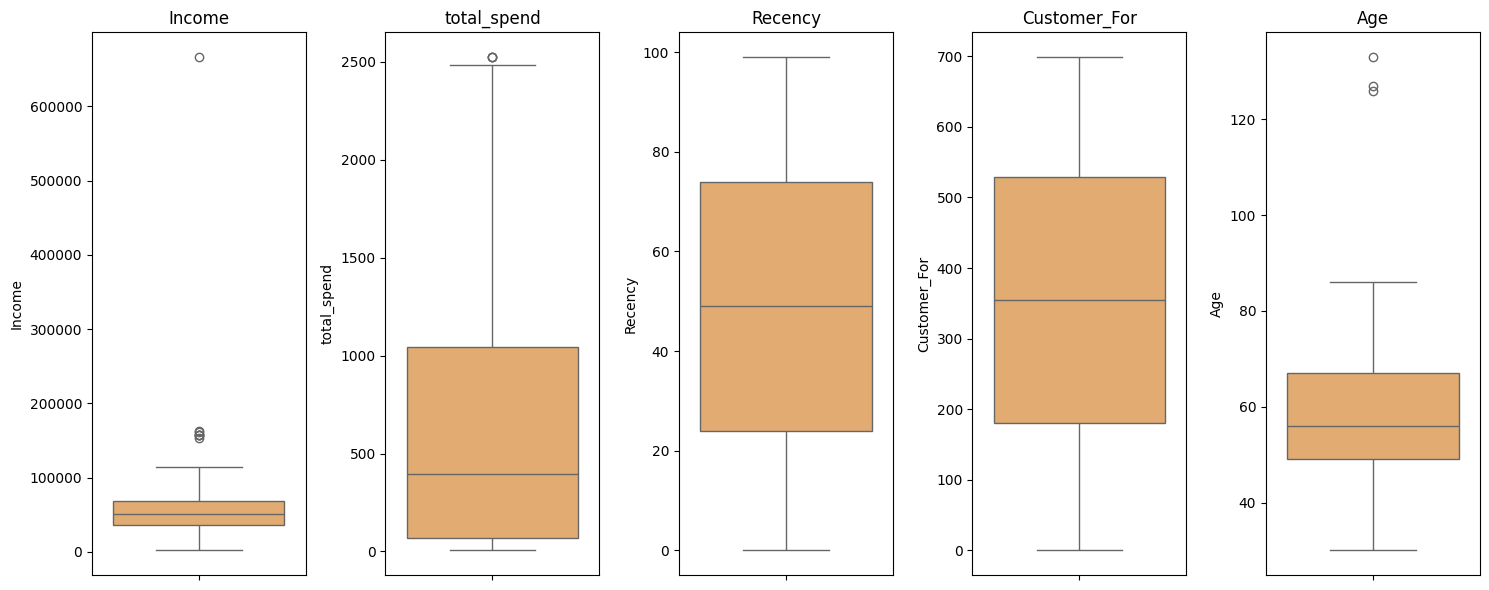

In [22]:
num_cols = ["Income", "total_spend", "Recency", "Customer_For", "Age"]

plt.figure(figsize=(15, 6))
for i, col in enumerate(num_cols, 1):
    plt.subplot(1, len(num_cols), i)
    sns.boxplot(y=df[col], color="#F3AB60")
    plt.title(col)

plt.tight_layout()
plt.show()

I can see that income and age have some outliers, so let's do outlier treatment (force-fitting).

## 5. Outlier Treatment (Force-fitting) <a id='outlier-treatment'></a>

In [23]:
# forcefit functions for outlier handling

import warnings

def cap_upper(s, q=0.995):
    """
    Force-fit monetary / exposure variables
    """
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)

        s = pd.to_numeric(s, errors='coerce').astype(float)
        s = s.replace([np.inf, -np.inf], np.nan)

        if not s.notna().any():
            return s

        upper = s.quantile(q)

        s_out = s.copy()
        s_out.loc[s_out > upper] = upper

        return s_out

def cap_ratio(s, low=-1, high=3):
    """
    Force-fit ratios (utilization, overdue ratios, paydown)
    Caps logical bounds, handles inf safely
    """
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)

        s = pd.to_numeric(s, errors='coerce').astype(float)
        s = s.replace([np.inf, -np.inf], np.nan)

        s_out = s.copy()
        s_out.loc[s_out < low] = low
        s_out.loc[s_out > high] = high

        return s_out

def cap_count(s, q=0.99, min_obs=50):
    """
    Force-fit discrete count variables with long right tails
    """
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)

        s = pd.to_numeric(s, errors='coerce').astype(float)

        if s.notna().sum() < min_obs:
            return s

        upper = s.quantile(q)

        s_out = s.copy()
        s_out.loc[s_out > upper] = upper

        return s_out

def cap_days(s, q=0.99, min_obs=50):
    """
    Force-fit tenure / recency variables
    Uses absolute values but keeps scale meaningful
    """
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)

        s = pd.to_numeric(s, errors='coerce').astype(float)

        if s.notna().sum() < min_obs:
            return s

        s_abs = s.abs()
        upper = s_abs.quantile(q)

        s_out = s_abs.copy()
        s_out.loc[s_out > upper] = upper

        return s_out

def safe_log1p(s):
    """
    Safe log1p transform for amount-like features.
    Applies log only where value >= 0.
    """
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)

        s = pd.to_numeric(s, errors='coerce')
        s = s.replace([np.inf, -np.inf], np.nan)

        s_out = pd.Series(np.nan, index=s.index)
        mask = s >= 0

        s_out.loc[mask] = np.log1p(s.loc[mask])

        return s_out

In [24]:
df_ff = df.copy()

In [25]:
# monetary variables
money_cols = [
    "Income", "MntWines", "MntFruits", "MntMeatProducts",
    "MntFishProducts", "MntSweetProducts",
    "MntGoldProds", "total_spend"
]

for col in money_cols:
    df_ff[col] = cap_upper(df_ff[col], q=0.995)
    df_ff[col] = safe_log1p(df_ff[col])

# count variables
count_cols = [
    "NumDealsPurchases", "NumWebPurchases",
    "NumCatalogPurchases", "NumStorePurchases",
    "NumWebVisitsMonth", "total_purchases",
    "campaign_accept_count"
]

for col in count_cols:
    df_ff[col] = cap_count(df_ff[col], q=0.99)

# ratio variables
ratio_cols = [
    "MntWines_ratio", "MntFruits_ratio", "MntMeatProducts_ratio",
    "MntFishProducts_ratio", "MntSweetProducts_ratio",
    "MntGoldProds_ratio",
    "web_purchase_ratio", "store_purchase_ratio",
    "catalog_purchase_ratio", "deal_purchase_ratio"
]

for col in ratio_cols:
    df_ff[col] = cap_ratio(df_ff[col], low=0, high=1)

# time/age variable
time_cols = ["Recency", "Customer_For", "Age"]

for col in time_cols:
    df_ff[col] = cap_days(df_ff[col])

In [26]:
df_ff.dtypes

ID                                 int64
Year_Birth                         int64
Education                         object
Marital_Status                    object
Income                           float64
Kidhome                            int64
Teenhome                           int64
Dt_Customer               datetime64[ns]
Recency                          float64
MntWines                         float64
MntFruits                        float64
MntMeatProducts                  float64
MntFishProducts                  float64
MntSweetProducts                 float64
MntGoldProds                     float64
NumDealsPurchases                float64
NumWebPurchases                  float64
NumCatalogPurchases              float64
NumStorePurchases                float64
NumWebVisitsMonth                float64
AcceptedCmp3                       int64
AcceptedCmp4                       int64
AcceptedCmp5                       int64
AcceptedCmp1                       int64
AcceptedCmp2    

In [27]:
df_ff.to_csv("data/processed/force_fitted_features.csv", index=False)

In [28]:
df=df_ff.copy()

## 6. Feature Selection for Clustering <a id='feature-selection'></a>

In [29]:
cluster_features = [
    # demographics and household
    'Income',
    'Age',
    'Customer_For',
    'num_children',

    # value & frequency
    'total_spend',
    'total_purchases',

    # product mix
    'MntWines_ratio',
    'MntMeatProducts_ratio',
    'MntGoldProds_ratio',

    # channel preference
    'web_purchase_ratio',
    'store_purchase_ratio',
    'catalog_purchase_ratio',
    'NumWebVisitsMonth',

    # promotion sensitivity
    'deal_purchase_ratio',
    'campaign_accept_count',

    # engagement
    'Recency'
]

In [30]:
cluster_features

['Income',
 'Age',
 'Customer_For',
 'num_children',
 'total_spend',
 'total_purchases',
 'MntWines_ratio',
 'MntMeatProducts_ratio',
 'MntGoldProds_ratio',
 'web_purchase_ratio',
 'store_purchase_ratio',
 'catalog_purchase_ratio',
 'NumWebVisitsMonth',
 'deal_purchase_ratio',
 'campaign_accept_count',
 'Recency']

In [31]:
X = df[cluster_features].copy()
X.to_csv("data/processed/features_unscaled.csv", index=False)

## 7. Feature Scaling <a id='feature-scaling'></a>

In [32]:
np.isinf(X).sum()

Income                    0
Age                       0
Customer_For              0
num_children              0
total_spend               0
total_purchases           0
MntWines_ratio            0
MntMeatProducts_ratio     0
MntGoldProds_ratio        0
web_purchase_ratio        0
store_purchase_ratio      0
catalog_purchase_ratio    0
NumWebVisitsMonth         0
deal_purchase_ratio       0
campaign_accept_count     0
Recency                   0
dtype: int64

In [33]:
np.isnan(X).sum()

Income                    0
Age                       0
Customer_For              0
num_children              0
total_spend               0
total_purchases           0
MntWines_ratio            0
MntMeatProducts_ratio     0
MntGoldProds_ratio        0
web_purchase_ratio        0
store_purchase_ratio      0
catalog_purchase_ratio    0
NumWebVisitsMonth         0
deal_purchase_ratio       0
campaign_accept_count     0
Recency                   0
dtype: int64

In [34]:
X = X.replace([np.inf, -np.inf], 0)
X = X.fillna(0)

In [35]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df.to_csv("data/processed/features_scaled.csv", index=False)

## 8. PCA for Clustering Model <a id='pca-for-clustering'></a>

#### Plot cumulative explained variance

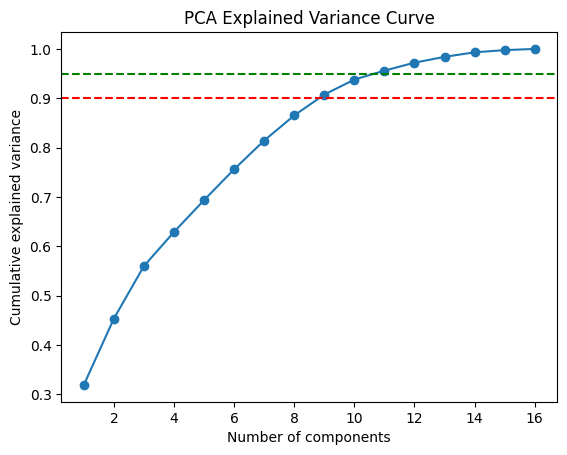

In [36]:
pca_full = PCA()
pca_full.fit(X_scaled)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.plot(range(1, len(cum_var)+1), cum_var, marker='o')
plt.axhline(y=0.90, color='r', linestyle='--')
plt.axhline(y=0.95, color='g', linestyle='--')
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA Explained Variance Curve")
plt.show()

#### Compare clustering quality

In [37]:
for var in [0.85, 0.90, 0.95]:
    pca = PCA(n_components=var, random_state=42)
    X_pca_tmp = pca.fit_transform(X_scaled)

    labels = KMeans(n_clusters=4, random_state=42, n_init=10)\
             .fit_predict(X_pca_tmp)

    score = silhouette_score(X_pca_tmp, labels)
    print(f"PCA {var:.2f} | components={X_pca_tmp.shape[1]} | silhouette={score:.3f}")

PCA 0.85 | components=8 | silhouette=0.170
PCA 0.90 | components=9 | silhouette=0.159
PCA 0.95 | components=11 | silhouette=0.149


In [38]:
pca_model = PCA(n_components=0.90, random_state=42)
X_pca = pca_model.fit_transform(X_scaled)

print("Original features:", X.shape[1])
print("PCA components used:", X_pca.shape[1])

Original features: 16
PCA components used: 9


In [39]:
# PCA loadings
loadings = pd.DataFrame(
    pca_model.components_,
    columns=X.columns,
    index=[f'PC{i+1}' for i in range(pca_model.components_.shape[0])]
)

# Saving PCA artifacts
loadings.to_csv("outputs/pca_components.csv")

# Saving explained variance
pd.Series(
    pca_model.explained_variance_ratio_,
    index=loadings.index
).to_csv("outputs/pca_explained_variance.csv")

#### Top contributing features per component

In [40]:
for pc in loadings.index:
    print(f"\n{pc}")
    print(loadings.loc[pc].abs().sort_values(ascending=False).head(5))


PC1
total_spend              0.401
total_purchases          0.381
Income                   0.366
catalog_purchase_ratio   0.337
deal_purchase_ratio      0.332
Name: PC1, dtype: float64

PC2
MntWines_ratio          0.492
web_purchase_ratio      0.409
MntMeatProducts_ratio   0.378
num_children            0.317
NumWebVisitsMonth       0.314
Name: PC2, dtype: float64

PC3
store_purchase_ratio   0.479
MntWines_ratio         0.370
web_purchase_ratio     0.367
Customer_For           0.344
MntGoldProds_ratio     0.339
Name: PC3, dtype: float64

PC4
MntMeatProducts_ratio   0.589
campaign_accept_count   0.443
MntGoldProds_ratio      0.405
Recency                 0.344
Customer_For            0.243
Name: PC4, dtype: float64

PC5
Recency                  0.704
Age                      0.383
MntGoldProds_ratio       0.332
catalog_purchase_ratio   0.284
MntMeatProducts_ratio    0.210
Name: PC5, dtype: float64

PC6
Customer_For            0.759
web_purchase_ratio      0.411
store_purchase_ratio    0

PCA is used before clustering as it reduces feature redundancy, stabilizes distance-based clustering and improves interpretability and robustness.

## 9. KMeans (Elbow + Silhouette) <a id='kmeans'></a>

In [41]:
inertia = []
sil_scores = []
K = range(2, 11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, labels))

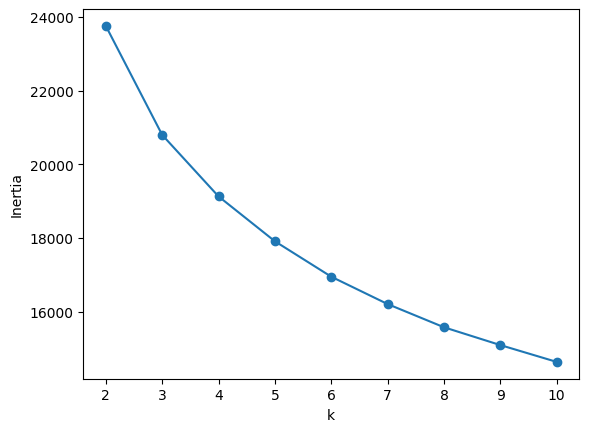

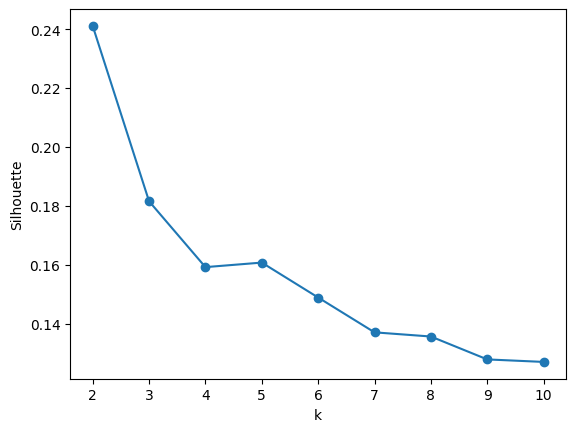

In [42]:
plt.plot(K, inertia, marker='o')
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()

plt.plot(K, sil_scores, marker='o')
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.show()

Elbow Method to determine the number of clusters to be formed:


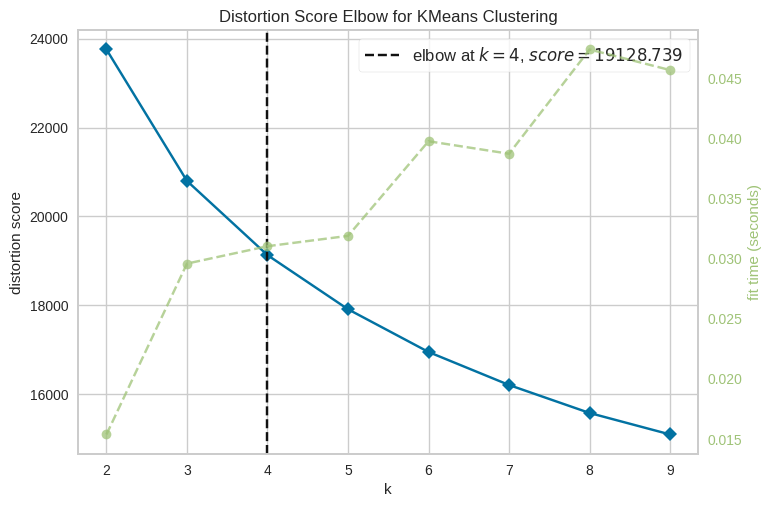

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [43]:
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans

print('Elbow Method to determine the number of clusters to be formed:')
Elbow_M = KElbowVisualizer(
    KMeans(random_state=42, n_init=10),
    k=(2, 10),
    metric='distortion'
)

Elbow_M.fit(X_pca)
Elbow_M.show()

In [44]:
pd.DataFrame({
    "k": K,
    "inertia": inertia,
    "silhouette": sil_scores
}).to_csv("outputs/kmeans_evaluation.csv", index=False)

## 10. Final Model (KMeans) <a id='final-model'></a>

#### KMeans

In [45]:
# Baseline comparison: clustering without PCA
kmeans_raw = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_raw = kmeans_raw.fit_predict(X_scaled)

In [46]:
# Final KMeans model with selected k
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_pca)

labels_pca = df['kmeans_cluster']

In [47]:
df.to_csv("data/processed/customer_clustered_data.csv", index=False)

#### Comparing PCA v/s non-PCA Clustering

In [48]:
# Final confirmation: PCA-based clustering vs raw features

print("Silhouette (raw):", silhouette_score(X_scaled, labels_raw))
print("Silhouette (PCA):", silhouette_score(X_pca, labels_pca))

Silhouette (raw): 0.1415622575490555
Silhouette (PCA): 0.15919144663995652


In [49]:
# sanity check - similar scores mean stable clusters
for seed in [0, 21, 42, 100]:
    km = KMeans(n_clusters=4, random_state=seed, n_init=10)
    labels = km.fit_predict(X_pca)
    print(seed, silhouette_score(X_pca, labels))

0 0.15956862818300102
21 0.1595404909417917
42 0.15919144663995652
100 0.1595404909417917


- PCA-based clustering achieved a higher silhouette score than raw features, indicating improved cluster separation after dimensionality reduction.
- Post outlier force-fitting, clustering performance remained stable across multiple random initializations, confirming robustness.
- A 4-cluster solution was selected to balance statistical quality with interpretability, enabling the identification of actionable customer segments.

## 11. PCA Visualization and Plots <a id='pca-visualization-and-plots'></a>

Using PCA in two ways: first, variance-based PCA to reduce dimensionality and remove correlation before clustering, and second, a separate 2-component PCA purely for visualization so stakeholders can interpret the segments.

In [50]:
pca_viz = PCA(n_components=2, random_state=42)
X_pca_2d = pca_viz.fit_transform(X_scaled)

df['pca1'] = X_pca_2d[:, 0]
df['pca2'] = X_pca_2d[:, 1]

explained = pca_viz.explained_variance_ratio_

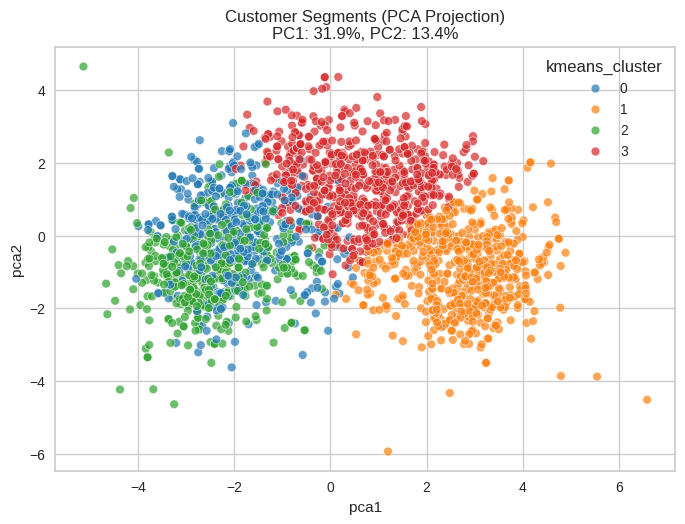

In [51]:
sns.scatterplot(
    data=df,
    x='pca1',
    y='pca2',
    hue='kmeans_cluster',
    palette='tab10',
    alpha=0.7,
    s=40
)

plt.title(
    f"Customer Segments (PCA Projection)\n"
    f"PC1: {explained[0]:.1%}, PC2: {explained[1]:.1%}"
)
plt.show()

#### 3D PCA cluster visualization
A 3D PCA projection reveals clear separation between clusters, validating the stability of the segmentation beyond 2D visualization.

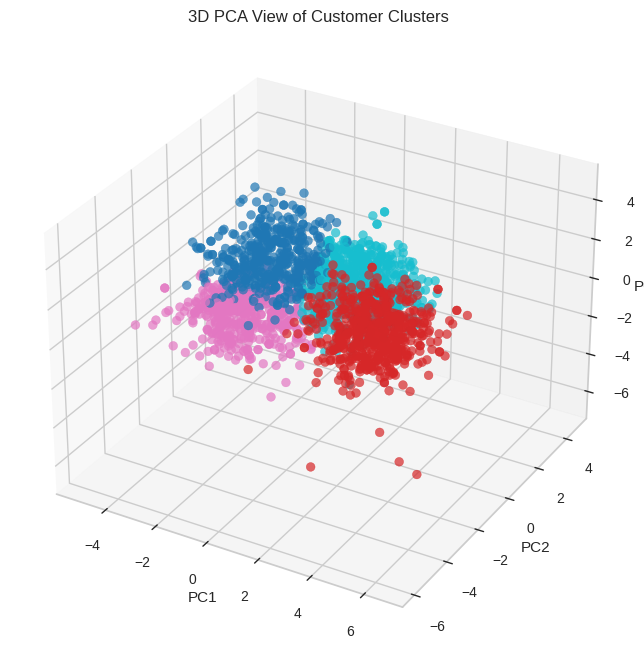

In [52]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA

pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_scaled)

df['pca1_3d'] = X_pca_3d[:, 0]
df['pca2_3d'] = X_pca_3d[:, 1]
df['pca3_3d'] = X_pca_3d[:, 2]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df['pca1_3d'],
    df['pca2_3d'],
    df['pca3_3d'],
    c=df['kmeans_cluster'],
    cmap='tab10',
    s=40,
    alpha=0.7
)

ax.set_title("3D PCA View of Customer Clusters")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

plt.show()

#### Cluster size distribution
The clusters are reasonably balanced, indicating that the segmentation does not suffer from extreme class imbalance.

/tmp/ipykernel_55/78255222.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




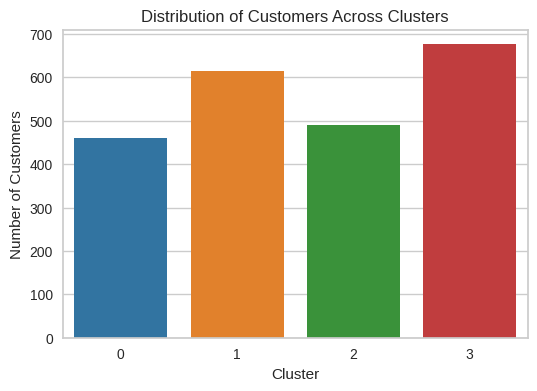

In [53]:
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x='kmeans_cluster', data=df, palette='tab10')
plt.title("Distribution of Customers Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.show()

#### Income vs Spending

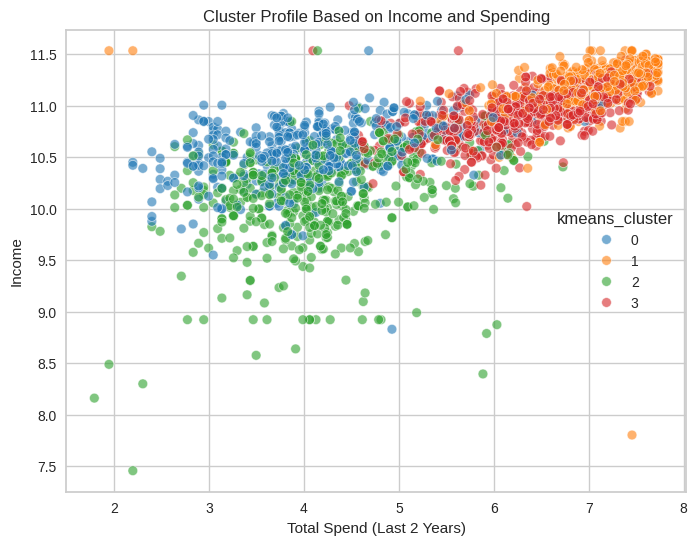

In [54]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x='total_spend',
    y='Income',
    hue='kmeans_cluster',
    palette='tab10',
    alpha=0.6
)

plt.title("Cluster Profile Based on Income and Spending")
plt.xlabel("Total Spend (Last 2 Years)")
plt.ylabel("Income")
plt.show()

Cluster 0: Moderate Income – Medium–High Spending (Value-driven but loyal customers)

Cluster 1: High Income – High Spending (Premium Customers)

Cluster 2: Low Income – Low Spending (Price Sensitive)

Cluster 3: Lower Income – High Spending (Deal-Driven / Risk Segment)

In [55]:
df.groupby('kmeans_cluster')[['Income', 'total_spend']].mean()

,Income,total_spend
kmeans_cluster,,
0,10.563,4.130
1,11.198,7.049
2,10.129,4.187
3,10.929,6.375


#### Observation:
Customer segmentation revealed four distinct behavioral personas based on income and spending patterns, highlighting premium customers, value-driven loyalists, price-sensitive customers, and promotion-driven high spenders. These insights will help in enabling targeted marketing strategies with optimized ROI.

#### Spending distribution per cluster

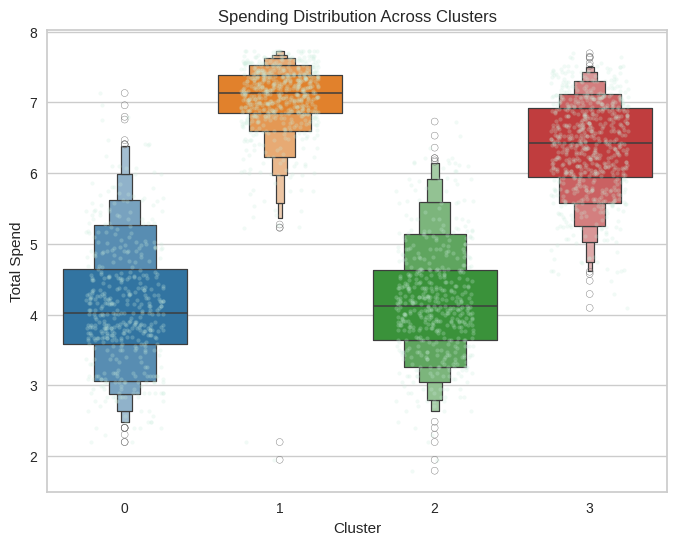

In [56]:
plt.figure(figsize=(8, 6))

sns.stripplot(
    x='kmeans_cluster',
    y='total_spend',
    data=df,
    color='#CBEDDD',
    alpha=0.25,
    jitter=0.25,
    size=3
)

sns.boxenplot(
    x='kmeans_cluster',
    y='total_spend',
    data=df,
    hue='kmeans_cluster',
    palette='tab10',
    legend=False
)

plt.title("Spending Distribution Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Total Spend")
plt.show()

#### Observation:
From the above plot, it can be clearly seen that cluster 1 represents the highest-spending customers, exhibiting the largest median and upper-range total spend. This is followed by cluster 3, which also shows consistently high spending behavior, though with slightly more variability. Clusters 0 and 2 form the lower-spending segments, with cluster 2 having the lowest overall spending distribution.

#### Income distribution per cluster

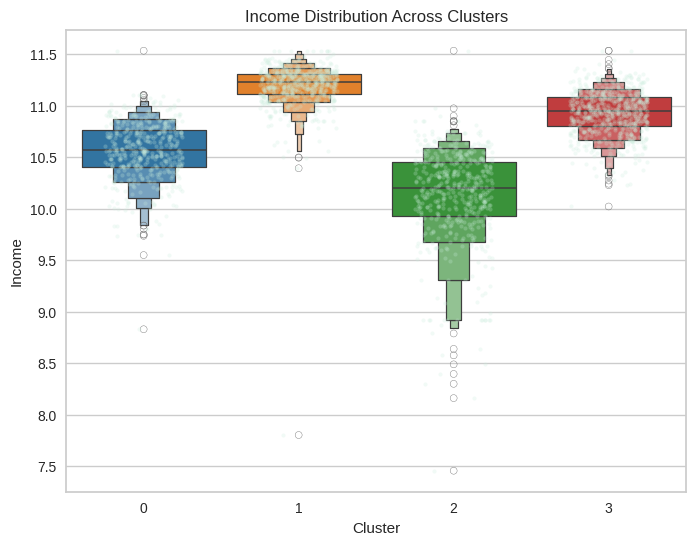

In [57]:
plt.figure(figsize=(8, 6))

sns.stripplot(
    x='kmeans_cluster',
    y='Income',
    data=df,
    color='#CBEDDD',
    alpha=0.25,
    jitter=0.25,
    size=3
)

sns.boxenplot(
    x='kmeans_cluster',
    y='Income',
    data=df,
    hue='kmeans_cluster',
    palette='tab10',
    legend=False
)

plt.title("Income Distribution Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Income")
plt.show()

#### Observations:
From the above plot, it can be clearly seen that cluster 1 has the highest income distribution, with a high median income and relatively low variability, indicating a financially strong and stable customer segment. Cluster 3 follows closely, also representing a high-income group but with slightly greater spread, suggesting more income diversity within the segment. Cluster 0 forms a mid-income customer group with a moderate and consistent income range, while cluster 2 represents the lowest-income segment, showing both a lower median and wider dispersion.

#### Campaign acceptance analysis

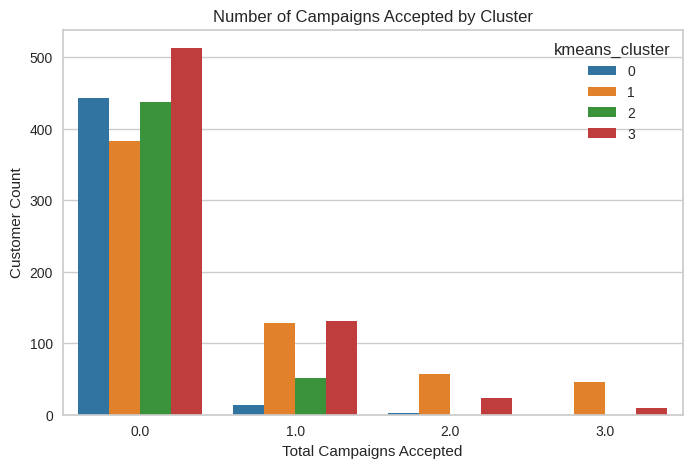

In [58]:
plt.figure(figsize=(8, 5))
sns.countplot(
    x='campaign_accept_count',
    hue='kmeans_cluster',
    data=df,
    palette='tab10'
)

plt.title("Number of Campaigns Accepted by Cluster")
plt.xlabel("Total Campaigns Accepted")
plt.ylabel("Customer Count")
plt.show()

#### Observations:
From the above plot, it is evident that campaign engagement is generally low across all clusters, with the majority of customers not accepting any campaigns at all. While clusters 1 and 3 show relatively higher participation, only a small fraction of customers in these groups accepted more than one campaign. Very few customers across clusters engaged with two or more campaigns, and none show consistent participation at higher counts. This suggests that past campaigns have not achieved strong traction overall, indicating a need for more targeted, personalized, and segment-specific marketing strategies to improve customer engagement and conversion.

#### Deal sensitivity

/tmp/ipykernel_55/2474453307.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




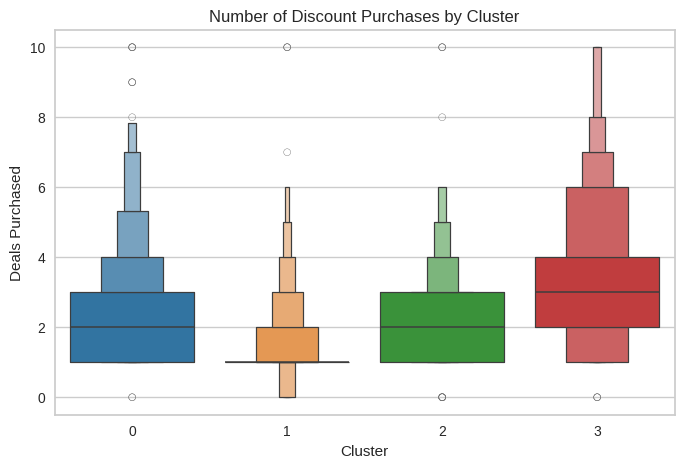

In [59]:
plt.figure(figsize=(8, 5))
sns.boxenplot(
    x='kmeans_cluster',
    y='NumDealsPurchases',
    data=df,
    palette='tab10'
)

plt.title("Number of Discount Purchases by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Deals Purchased")
plt.show()

#### Observations:
Unlike campaign acceptance, discount-based purchases show relatively stronger engagement across clusters. Clusters 0 and 3 respond most positively to deals, indicating higher price sensitivity and a clear inclination toward promotions. Cluster 1, despite being high-value customers, shows limited reliance on discounts, suggesting that deals are not a primary driver for their purchases. Cluster 2 displays moderate but inconsistent deal usage, with no strong preference toward discounts. Overall, this indicates that discount strategies are effective for clusters 0 and 3, while clusters 1 and 2 may require value-driven or experience-based incentives rather than price cuts.

#### Product-wise spending

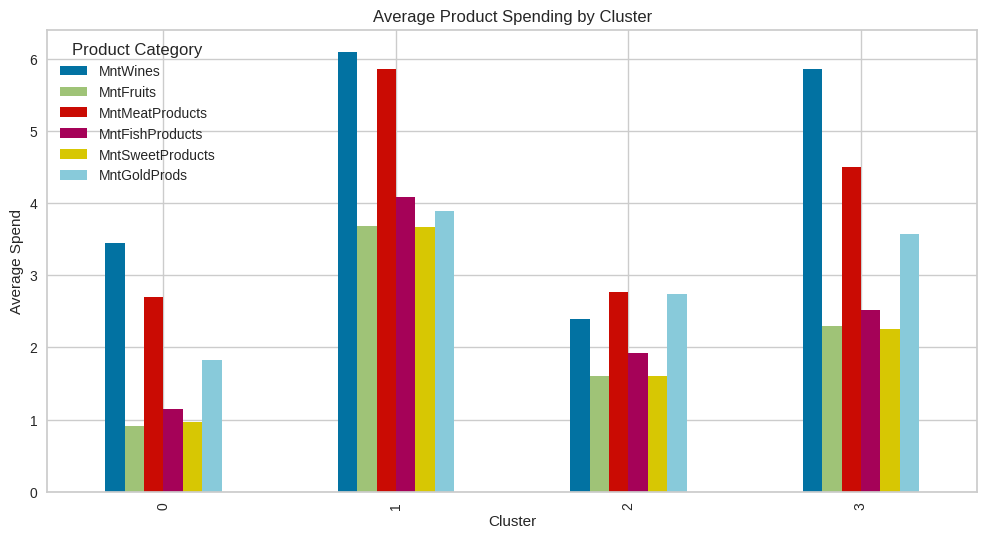

In [60]:
product_means = (
    df.groupby('kmeans_cluster')[spend_cols]
      .mean()
)

product_means.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title("Average Product Spending by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Spend")
plt.legend(title="Product Category")
plt.show()

#### Observations:
From the above plot, it can be observed that product preferences vary significantly across clusters. Cluster 1 emerges as the strongest overall spender across all product categories, particularly in Wines and Meat Products, indicating premium and diversified consumption behavior. Cluster 3 also shows high spending, with a strong preference for Wines and Meat Products, though at slightly lower levels than Cluster 1. Cluster 0 demonstrates moderate spending, mainly concentrated in Wines, while Cluster 2 consistently shows the lowest average spend across all categories, suggesting a more conservative or value-oriented purchasing pattern. These differences highlight clear opportunities for category-specific and cluster-targeted product promotions.

## 12. Cluster Profiling <a id='cluster-profiling'></a>

In [62]:
cluster_profile = (
    df.groupby('kmeans_cluster')[cluster_features]
      .mean()
      .sort_values('total_spend', ascending=False)
)

cluster_profile.to_csv("outputs/kmeans_cluster_profiles.csv")
cluster_profile

,Income,Age,Customer_For,num_children,total_spend,total_purchases,MntWines_ratio,MntMeatProducts_ratio,MntGoldProds_ratio,web_purchase_ratio,store_purchase_ratio,catalog_purchase_ratio,NumWebVisitsMonth,deal_purchase_ratio,campaign_accept_count,Recency
kmeans_cluster,,,,,,,,,,,,,,,,
1,11.198,58.094,328.764,0.244,7.049,18.961,0.423,0.331,0.065,0.248,0.442,0.306,2.596,0.074,0.619,49.850
3,10.929,60.595,420.873,1.120,6.375,16.231,0.631,0.174,0.086,0.397,0.435,0.168,6.120,0.225,0.302,48.283
2,10.129,49.465,379.692,0.929,4.187,5.637,0.198,0.253,0.252,0.361,0.546,0.085,6.973,0.343,0.106,50.131
0,10.563,58.852,259.811,1.667,4.130,5.804,0.528,0.248,0.104,0.302,0.644,0.054,5.833,0.379,0.043,48.211


## 13. Final Customer Segmentation and Profiling <a id='final-customer-segmentation'></a>

Based on spending behavior, income distribution, campaign engagement, discount responsiveness, and product-level preferences, four distinct and actionable customer segments emerge. Each cluster represents a unique customer persona with clear business implications.

---

### 🔵 Cluster 0: Moderate Income – Medium–High Spending (Value-Driven Loyal Customers)

- Cluster 0 represents customers with moderate and stable income levels who exhibit medium to relatively high spending behavior. While they are not the top spenders overall, their spending distribution is consistent, indicating dependable purchasing patterns.

- These customers show strong responsiveness to discounts, suggesting price sensitivity and a value-seeking mindset. However, their engagement with marketing campaigns remains low, indicating that traditional campaigns may not resonate strongly with them.

- From a product perspective, their spending is moderately concentrated on Wines, with lower but steady contributions across other categories.

#### Business insight:
This segment is ideal for loyalty programs, bundle offers, and discount-led promotions. Retaining them through consistent value propositions can ensure steady revenue over time.

---

### 🟠 Cluster 1: High Income – High Spending (Premium Customers)

- Cluster 1 clearly stands out as the most valuable customer segment. These customers exhibit the highest income levels with low variability, indicating financial stability, and they also demonstrate the highest total spending, with strong upper-range values.

- They are least responsive to discounts, suggesting that price is not a primary decision factor. While campaign participation is slightly better than other clusters, overall engagement is still limited.

- Product-wise, Cluster 1 shows dominant spending across all categories, especially Wines and Meat Products, highlighting a premium and diversified consumption pattern.

#### Business insight:
This is your VIP segment. Instead of discounts, they should be targeted with exclusive offers, premium product launches, personalized recommendations, and experience-based marketing to maximize lifetime value.

---

### 🟢 Cluster 2: Low Income – Low Spending (Price-Sensitive Customers)

- Cluster 2 represents the lowest-income group, with the widest income dispersion and the lowest overall spending levels across all metrics. Their spending distribution is consistently at the lower end.

- They show minimal engagement with campaigns and discounts.

- Product-level spending is also the lowest across categories, indicating conservative purchasing behavior and limited discretionary spending.

#### Business insight:
This segment is highly price-sensitive but difficult to activate. Aggressive marketing spend may not yield strong returns. Instead, low-cost essentials, basic value packs, or passive retention strategies are more appropriate for this group.

---

### 🔴 Cluster 3: Lower Income – High Spending (Deal-Driven / Risk Segment)

- Cluster 3 presents an interesting and high-impact segment. Despite having lower income compared to Cluster 1, these customers demonstrate consistently high spending, second only to premium customers.

- They show the highest responsiveness to discounts and relatively better campaign engagement compared to other clusters. This indicates that promotions and deals strongly influence their purchasing decisions.

- In terms of products, Cluster 3 spends heavily on Wines and Meat Products, closely mirroring premium customers, but with higher variability and greater reliance on incentives.

#### Business insight:
This is a deal-driven but high-revenue segment. While they generate strong sales, their spending may be promotion-dependent. Targeted discount strategies should be carefully optimized to drive volume without eroding margins.

---

### Overall Strategic Takeaways

- Cluster 1 drives the highest value → focus on exclusivity, not discounts

- Cluster 3 responds strongly to promotions → high ROI but margin-sensitive

- Cluster 0 offers stable revenue → ideal for loyalty and value bundles

- Cluster 2 contributes least → low-cost, selective engagement recommended